# 236. Where does the close-range win end? Fmax against divergence on Pfam (experiment 3)

On family-labelled truth (Pfam, free of the transmembrane artifact of nb 231), the report
has kmerseek close to the aligners at mouse and far below them by E. coli. This notebook
reads the divergence at which kmerseek stops keeping up off the curve, tool by tool, on the
midi-plus aggregate (`extract/all_domain_metrics.parquet`, `dedup_transfers=True`,
Pfam truth, heldout split so the alphabet was not chosen on the data it is scored on;
the `all` split is shown for comparison). kmerseek is its best arm by mean heldout Fmax.

The second half of the experiment, whether Seanome's use case sits inside the window,
needs a divergence estimate from Mactromeris to its nearest annotated relative and the
dark-set run on Sherlock; it is set up at the end, not answered here.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

sys.path.insert(0, str(Path.cwd()))
import hp_conservation_utils as hc

pl.Config.set_tbl_rows(60)
pl.Config.set_tbl_width_chars(220)
FIG = Path("../figures")
m = pl.read_parquet(
    "/Users/olga/data/qfo-pfam-region-midi-plus/extract/all_domain_metrics.parquet"
)
base = m.filter(
    (pl.col("truth_set") == "pfam")
    & (pl.col("stratum_axis") == "all")
    & pl.col("dedup_transfers")
    & pl.col("species_mya").is_not_null()
)
TOOL_LABEL = {
    "kmerseek": "kmerseek",
    "hhblits": "HHblits",
    "hmmer3_phmmer": "phmmer",
    "hmmer3_jackhmmer": "jackhmmer",
    "mmseqs2_seqseq": "MMseqs2",
    "mmseqs2_iterative": "MMseqs2 iter.",
    "foldseek": "Foldseek",
    "reseek": "Reseek",
    "prostt5": "ProstT5",
    "folddisco": "Folddisco",
}
TOOL_COLOR = {
    "kmerseek": "#a50f15",
    "hhblits": "#1f77b4",
    "hmmer3_phmmer": "#6baed6",
    "hmmer3_jackhmmer": "#9ecae1",
    "mmseqs2_seqseq": "#bcbddc",
    "mmseqs2_iterative": "#756bb1",
    "foldseek": "#2ca02c",
    "reseek": "#98df8a",
    "prostt5": "#8c564b",
    "folddisco": "#7f7f7f",
}


def curves(split):
    h = base.filter(pl.col("split") == split)
    best = (
        h.group_by("tool", "variant")
        .agg(pl.col("fmax").mean())
        .sort("fmax", descending=True)
        .group_by("tool")
        .first()
    )
    t = (
        h.join(best.select("tool", "variant"), on=["tool", "variant"])
        .select("tool", "variant", "species", "species_mya", "fmax")
        .sort("tool", "species_mya")
    )
    return t, best


held, best_h = curves("heldout")
print("best arm per tool, heldout mean Fmax:")
print(best_h.sort("fmax", descending=True))

best arm per tool, heldout mean Fmax:
shape: (10, 3)
┌───────────────────┬──────────────────┬──────────┐
│ tool              ┆ variant          ┆ fmax     │
│ ---               ┆ ---              ┆ ---      │
│ str               ┆ str              ┆ f64      │
╞═══════════════════╪══════════════════╪══════════╡
│ mmseqs2_iterative ┆ s7               ┆ 0.408482 │
│ hhblits           ┆ single_seq       ┆ 0.407036 │
│ hmmer3_phmmer     ┆ default          ┆ 0.406637 │
│ mmseqs2_seqseq    ┆ s7               ┆ 0.392164 │
│ hmmer3_jackhmmer  ┆ n3               ┆ 0.363825 │
│ foldseek          ┆ 3di_aa           ┆ 0.322622 │
│ prostt5           ┆ 3di_from_seq     ┆ 0.27488  │
│ reseek            ┆ verysensitive    ┆ 0.210426 │
│ folddisco         ┆ motif            ┆ 0.180711 │
│ kmerseek          ┆ gbmr4_k21_lcTrue ┆ 0.129156 │
└───────────────────┴──────────────────┴──────────┘


## 1. Fmax against divergence, every tool

shape: (10, 10)
┌───────────────────┬───────┬─────────┬───────────┬───┬───────┬───────┬─────────────┬───────┐
│ tool              ┆ mouse ┆ chicken ┆ zebrafish ┆ … ┆ worm  ┆ yeast ┆ arabidopsis ┆ ecoli │
│ ---               ┆ ---   ┆ ---     ┆ ---       ┆   ┆ ---   ┆ ---   ┆ ---         ┆ ---   │
│ str               ┆ f64   ┆ f64     ┆ f64       ┆   ┆ f64   ┆ f64   ┆ f64         ┆ f64   │
╞═══════════════════╪═══════╪═════════╪═══════════╪═══╪═══════╪═══════╪═════════════╪═══════╡
│ folddisco         ┆ 0.525 ┆ 0.242   ┆ 0.281     ┆ … ┆ 0.105 ┆ 0.071 ┆ 0.077       ┆ 0.037 │
│ foldseek          ┆ 0.353 ┆ 0.325   ┆ 0.354     ┆ … ┆ 0.369 ┆ 0.308 ┆ 0.339       ┆ 0.157 │
│ hhblits           ┆ 0.439 ┆ 0.429   ┆ 0.458     ┆ … ┆ 0.466 ┆ 0.379 ┆ 0.38        ┆ 0.166 │
│ hmmer3_jackhmmer  ┆ 0.402 ┆ 0.391   ┆ 0.397     ┆ … ┆ 0.426 ┆ 0.32  ┆ 0.351       ┆ 0.136 │
│ hmmer3_phmmer     ┆ 0.452 ┆ 0.46    ┆ 0.467     ┆ … ┆ 0.482 ┆ 0.349 ┆ 0.384       ┆ 0.124 │
│ kmerseek          ┆ 0.471 ┆ 0.213   ┆ 0.24

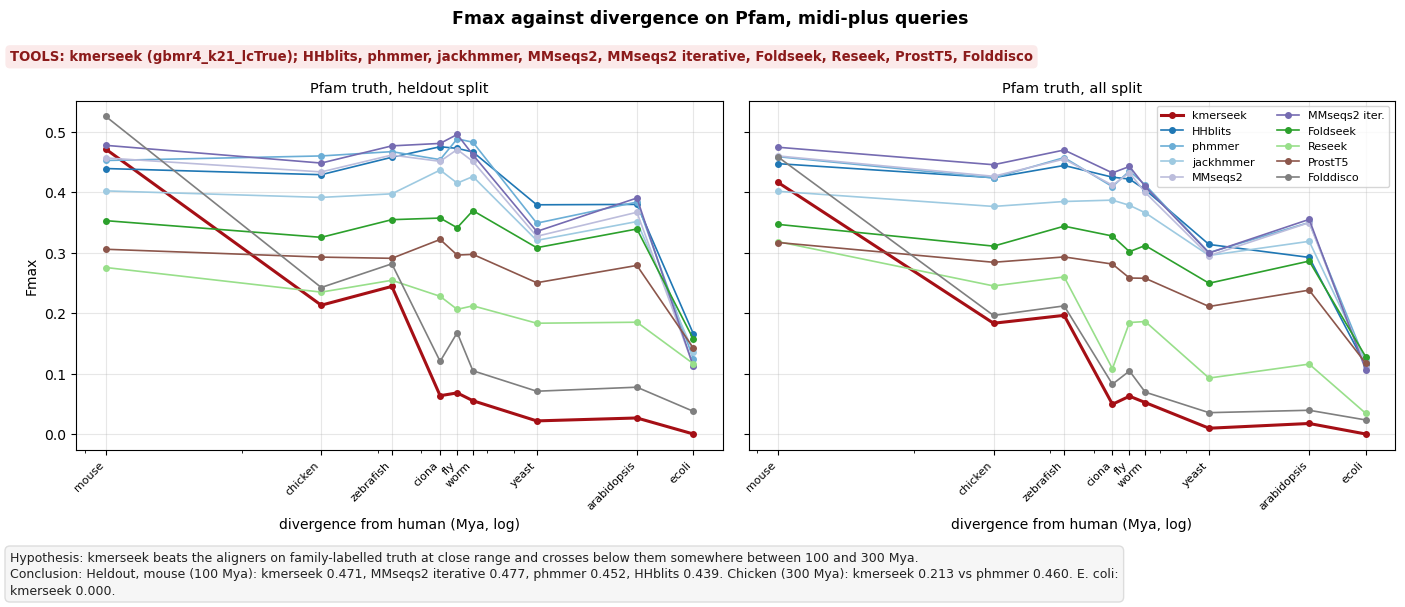

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), sharey=True)
for ax, split in zip(axes, ["heldout", "all"]):
    t, _ = curves(split)
    for tool in TOOL_LABEL:
        s = t.filter(pl.col("tool") == tool)
        if s.height:
            ax.plot(
                s["species_mya"],
                s["fmax"],
                marker="o",
                ms=4,
                color=TOOL_COLOR[tool],
                lw=2.2 if tool == "kmerseek" else 1.2,
                label=TOOL_LABEL[tool],
            )
    sp = t.select("species", "species_mya").unique().sort("species_mya")
    ax.set_xscale("log")
    ax.set_xticks(sp["species_mya"], sp["species"], rotation=45, ha="right", fontsize=8)
    ax.set_xlabel("divergence from human (Mya, log)")
    ax.set_title(f"Pfam truth, {split} split", fontsize=10.5)
    ax.grid(alpha=0.3)
axes[0].set_ylabel("Fmax")
axes[1].legend(fontsize=8, ncol=2)
wide = held.pivot(on="species", index="tool", values="fmax")
print(
    wide.select(
        ["tool"]
        + held.select("species", "species_mya")
        .unique()
        .sort("species_mya")["species"]
        .to_list()
    ).with_columns(pl.all().exclude("tool").round(3))
)
km = held.filter(pl.col("tool") == "kmerseek")


def at(tool, sp):
    return held.filter((pl.col("tool") == tool) & (pl.col("species") == sp))["fmax"][0]


hc.finish_figure(
    fig,
    FIG / "236_fmax_vs_divergence_pfam.png",
    tools=f"kmerseek ({km['variant'][0]}); HHblits, phmmer, jackhmmer, MMseqs2, MMseqs2 iterative, Foldseek, Reseek, ProstT5, Folddisco",
    hypothesis="kmerseek beats the aligners on family-labelled truth at close range and crosses below them somewhere between 100 and 300 Mya.",
    conclusion=(
        f"Heldout, mouse (100 Mya): kmerseek {at('kmerseek', 'mouse'):.3f}, MMseqs2 iterative {at('mmseqs2_iterative', 'mouse'):.3f}, phmmer {at('hmmer3_phmmer', 'mouse'):.3f}, HHblits {at('hhblits', 'mouse'):.3f}. "
        f"Chicken (300 Mya): kmerseek {at('kmerseek', 'chicken'):.3f} vs phmmer {at('hmmer3_phmmer', 'chicken'):.3f}. E. coli: kmerseek {at('kmerseek', 'ecoli'):.3f}."
    ),
    title="Fmax against divergence on Pfam, midi-plus queries",
)

## 2. The crossover, read off the curve

For each aligner, the divergence at which kmerseek's Fmax falls below it, by linear
interpolation in log(Mya) between the two species that bracket the sign change. A
crossover "before mouse" means kmerseek is already below at the closest target.

shape: (6, 4)
┌───────────────┬─────────────────────────────┬──────────────┬───────────────┐
│ aligner       ┆ kmerseek - aligner at mouse ┆ crossover    ┆ crossover_mya │
│ ---           ┆ ---                         ┆ ---          ┆ ---           │
│ str           ┆ f64                         ┆ str          ┆ f64           │
╞═══════════════╪═════════════════════════════╪══════════════╪═══════════════╡
│ phmmer        ┆ 0.019                       ┆ 108 Mya      ┆ 108.086438    │
│ MMseqs2       ┆ 0.015                       ┆ 107 Mya      ┆ 107.059277    │
│ MMseqs2 iter. ┆ -0.006                      ┆ before mouse ┆ NaN           │
│ HHblits       ┆ 0.032                       ┆ 115 Mya      ┆ 115.299332    │
│ jackhmmer     ┆ 0.069                       ┆ 136 Mya      ┆ 135.918731    │
│ Foldseek      ┆ 0.118                       ┆ 176 Mya      ┆ 175.736444    │
└───────────────┴─────────────────────────────┴──────────────┴───────────────┘


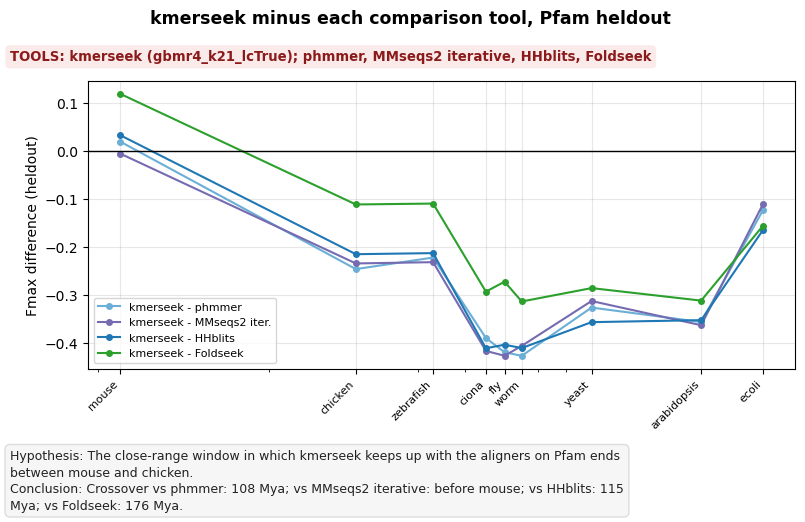

In [3]:
rows = []
kmv = km.sort("species_mya")
for tool in [
    "hmmer3_phmmer",
    "mmseqs2_seqseq",
    "mmseqs2_iterative",
    "hhblits",
    "hmmer3_jackhmmer",
    "foldseek",
]:
    o = held.filter(pl.col("tool") == tool).sort("species_mya")
    j = kmv.join(o, on="species_mya", suffix="_o").sort("species_mya")
    diff = (j["fmax"] - j["fmax_o"]).to_numpy()
    mya = j["species_mya"].to_numpy()
    if diff[0] < 0:
        cross = "before mouse"
        val = np.nan
    else:
        idx = np.flatnonzero(diff < 0)
        if idx.size == 0:
            cross = "never"
            val = np.nan
        else:
            i = idx[0]
            x0, x1 = np.log10(mya[i - 1]), np.log10(mya[i])
            d0, d1 = diff[i - 1], diff[i]
            val = 10 ** (x0 + (x1 - x0) * d0 / (d0 - d1))
            cross = f"{val:.0f} Mya"
    rows.append(
        {
            "aligner": TOOL_LABEL[tool],
            "kmerseek - aligner at mouse": float(diff[0]),
            "crossover": cross,
            "crossover_mya": val,
        }
    )
cx = pl.DataFrame(rows)
print(cx.with_columns(pl.col("kmerseek - aligner at mouse").round(3)))
fig, ax = plt.subplots(figsize=(8, 3.8))
for tool in ["hmmer3_phmmer", "mmseqs2_iterative", "hhblits", "foldseek"]:
    o = held.filter(pl.col("tool") == tool).sort("species_mya")
    j = kmv.join(o, on="species_mya", suffix="_o").sort("species_mya")
    ax.plot(
        j["species_mya"],
        j["fmax"] - j["fmax_o"],
        marker="o",
        ms=4,
        color=TOOL_COLOR[tool],
        label=f"kmerseek - {TOOL_LABEL[tool]}",
    )
ax.axhline(0, color="k", lw=1)
ax.set_xscale("log")
sp = held.select("species", "species_mya").unique().sort("species_mya")
ax.set_xticks(sp["species_mya"], sp["species"], rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Fmax difference (heldout)")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
c = {r["aligner"]: r["crossover"] for r in cx.iter_rows(named=True)}
hc.finish_figure(
    fig,
    FIG / "236_crossover.png",
    tools=f"kmerseek ({km['variant'][0]}); phmmer, MMseqs2 iterative, HHblits, Foldseek",
    hypothesis="The close-range window in which kmerseek keeps up with the aligners on Pfam ends between mouse and chicken.",
    conclusion=f"Crossover vs phmmer: {c['phmmer']}; vs MMseqs2 iterative: {c['MMseqs2 iter.']}; vs HHblits: {c['HHblits']}; vs Foldseek: {c['Foldseek']}.",
    title="kmerseek minus each comparison tool, Pfam heldout",
)

## 3. Is the window Seanome's? (set up, not answered)

Two numbers decide it: the crossover above, and the divergence from *Mactromeris* to the
nearest proteome with a usable Pfam annotation. The second needs (a) a TimeTree estimate
for Mactromeris vs the nearest annotated bivalves (Mercenaria mercenaria and Ruditapes
philippinarum are the same order, Venerida; Crassostrea gigas and Mytilus are other orders)
and (b) the dark-set run, which searches Mactromeris against those relatives. Neither is a
local computation. If the crossover is about 150 Mya and the nearest annotated relative is
farther than that, the close-range win is real and not Seanome's to use; if a same-order
annotated relative sits inside the window, it is.